# TD 02 - Regression NLP (ML)

## Objectif du TD
Construire un pipeline NLP simple pour predire une note numerique a partir d'un texte.

Probleme a resoudre: predire la note (1 a 10) d'un avis patient.

Pipeline vise:
1) pretraitement,
2) vectorisation texte,
3) entrainement de modeles de regression,
4) evaluation avec MAE, MSE, RMSE, R2.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

## Etape 1 - Charger et explorer le dataset

Dataset impose (regression): `Mouwiya/drug-reviews`.

A faire:
- charger le dataset,
- afficher les colonnes,
- identifier la colonne texte et la colonne cible numerique.

In [ ]:
from datasets import load_dataset

# 1) Chargement du dataset
ds = load_dataset("Mouwiya/drug-reviews")
TEXT_COL = "review"
Y_COL = "rating"

# On limite la taille pour garder un TD rapide a executer
N = min(10000, len(ds["train"]))
X_raw = list(ds["train"][TEXT_COL][:N])
y = np.array(ds["train"][Y_COL][:N], dtype=float)

print("Nombre d'exemples utilises:", N)
print("Note minimale:", min(y), " | Note maximale:", max(y))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/9.57M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/27703 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/46108 [00:00<?, ? examples/s]

Nombre d'exemples utilises: 15000
Note minimale: 1.0  | Note maximale: 10.0


## Etape 2 - Pretraitement de base

A faire:
- minuscules,
- suppression ponctuation/accents,
- stopwords,
- stemming optionnel.

In [ ]:
import re
import unicodedata
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# 2) Pretraitement simple
def preprocess_text(text):
    text = text.lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8", "ignore")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = [tok for tok in text.split() if tok not in ENGLISH_STOP_WORDS]
    return " ".join(tokens)

X = [preprocess_text(t) for t in X_raw]


## Etape 3 - Split train / validation

A faire:
- creer X et y,
- split train/validation,
- verifier les tailles.

In [ ]:
from sklearn.model_selection import train_test_split

# 3) Split train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Train:", len(X_train), "| Validation:", len(X_val))

Train: 12000 | Validation: 3000


## Etape 4 - Vectorizer + modeles de regression

A faire:
- definir un `TfidfVectorizer`,
- comparer au moins:
  - LinearRegression,
  - Ridge(alpha=1),
  - Ridge(alpha=10).

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge

# 4) Pipelines simples
bow = CountVectorizer(max_features=30000, ngram_range=(1, 2))
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)

models = {
    "BoW + LinearRegression": Pipeline([
        ("vec", bow),
        ("reg", LinearRegression()),
    ]),
    "TFIDF + Ridge(alpha=1)": Pipeline([
        ("vec", tfidf),
        ("reg", Ridge(alpha=1.0)),
    ]),
    "TFIDF + Ridge(alpha=10)": Pipeline([
        ("vec", tfidf),
        ("reg", Ridge(alpha=10.0)),
    ]),
}


## Etape 5 - Evaluation

Metriques a calculer:
- MAE,
- MSE,
- RMSE,
- R2.

,Modele,MAE,MSE,RMSE,R2
1,TFIDF + Ridge(alpha=1),1.9472,6.0267,2.4549,0.4299
2,TFIDF + Ridge(alpha=10),2.2222,7.1268,2.6696,0.3258
0,BoW + LinearRegression,2.5857,11.3734,3.3724,-0.0759


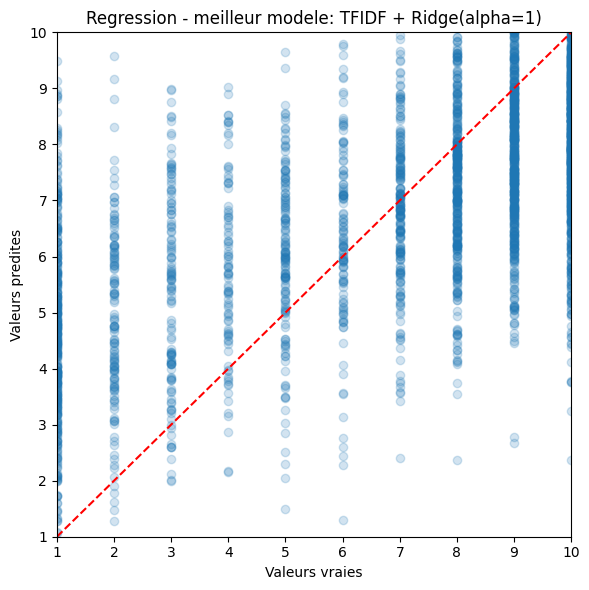

Meilleur modele (MAE): TFIDF + Ridge(alpha=1)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 5) Evaluation
rows = []
best_name = None
best_model = None
best_mae = np.inf

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, pred)
    mse = mean_squared_error(y_val, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, pred)

    rows.append({
        "Modele": name,
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4),
    })

    if mae < best_mae:
        best_mae = mae
        best_name = name
        best_model = model

results_df = pd.DataFrame(rows).sort_values("MAE")
display(results_df)

# Visualisation simple vrai vs predit (meilleur modele)
pred_best = best_model.predict(X_val)
plt.figure(figsize=(6, 6))
plt.scatter(y_val, pred_best, alpha=0.2)
plt.xlabel("Valeurs vraies")
plt.ylabel("Valeurs predites")
plt.title(f"Regression - meilleur modele: {best_name}")
plt.plot([1, 10], [1, 10], "r--")
plt.xlim(1, 10)
plt.ylim(1, 10)
plt.tight_layout()
plt.show()

print("Meilleur modele (MAE):", best_name)


## Etape 6 - Interpretation rapide

Ecrire une conclusion courte:
- quel modele est le plus stable,
- MAE/RMSE: est-ce acceptable ou non,
- difference entre Ridge alpha=1 et alpha=10.